# Demo 2: AUTO-07P Benchmark Demo `ab` (A-B Exothermic Reaction)

In this tutorial, we reproduce the classic **AUTO-07P benchmark demo `ab`** (Continuous Stirred-Tank Reactor model for an exothermic reaction $A \to B$) using **`bifurx`**.

### Learning Objectives:
1. Model nonlinear chemical reaction dynamics with Arrhenius kinetics in JAX.
2. Track the classic **S-shaped equilibrium curve** through two **Fold / Limit Points (LP 1 and LP 2)**.
3. Automatically detect and refine Fold points using the **Moore-Spence augmented system**.
4. Detect the **Hopf Bifurcation (HB)** point where oscillatory limit cycles are born.
5. Analyze the eigenvalue spectrum and stability transitions along the branch.
6. Visualize the bifurcation diagrams for both conversion and reactor temperature.

---

## 1. Mathematical Model and Dynamics

The model describes an exothermic first-order chemical reaction $A \to B$ in a CSTR:

$$\begin{cases}
\dfrac{du_1}{dt} = -u_1 + p_1 (1 - u_1) e^{u_2} = 0 \\[1ex]
\dfrac{du_2}{dt} = -u_2 + p_1 p_2 (1 - u_1) e^{u_2} - p_3 u_2 = 0
\end{cases}$$

### Physical Meaning of Variables and Parameters:
- $u_1$: Reactant conversion fraction ($0 \le u_1 \le 1$).
- $u_2$: Dimensionless temperature rise.
- $p_1$: **Damköhler number** (ratio of characteristic flow time to chemical reaction time). This is our primary **continuation parameter**.
- $p_2 = 14.0$: Dimensionless adiabatic temperature rise (exothermicity / heat of reaction).
- $p_3 = 2.0$: Dimensionless cooling capacity (heat transfer coefficient).

The exponential Arrhenius factor $e^{u_2}$ creates nonlinear positive feedback: higher temperature increases reaction rate, which generates more heat, leading to ignition, extinction, and limit cycle oscillations.

---

### AUTO-07P Benchmark Reference Values
From the official AUTO-07P documentation (`doc/tutorial.tex`, demo `ab`):
- **Limit Point 1 (Ignition)**: $p_1 = 0.1057390, \quad u_1 = 0.3110230, \quad u_2 = 1.451441$
- **Limit Point 2 (Extinction)**: $p_1 = 0.08893185, \quad u_1 = 0.6889822, \quad u_2 = 3.215250$
- **Hopf Bifurcation (HB)**: $p_1 = 0.1308998, \quad u_1 = 0.8950803, \quad u_2 = 4.177042$


In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from bifurx import (
    BifurcationProblem,
    continuation,
    plot_diagram,
)

# Enable 64-bit precision for high-accuracy numerical continuation
jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")


JAX version: 0.11.1


## 2. Defining the Model in JAX

We fix $p_2 = 14.0$ and $p_3 = 2.0$ as benchmark constants and set $p_1$ as the continuation parameter.


In [2]:
P2 = 14.0  # Dimensionless heat of reaction
P3 = 2.0   # Dimensionless cooling coefficient

def f_ab(u: jnp.ndarray, p1: float) -> jnp.ndarray:
    u1, u2 = u[0], u[1]
    e = jnp.exp(u2)
    f1 = -u1 + p1 * (1.0 - u1) * e
    f2 = -u2 + p1 * P2 * (1.0 - u1) * e - P3 * u2
    return jnp.array([f1, f2])

# Initialize starting from zero conversion and ambient temperature at p1 = 0
prob = BifurcationProblem(f_ab, u0=[0.0, 0.0], p0=0.0)

print(f"State dimension: {prob.dim}")
print(f"Residual at initial equilibrium (0, 0): {prob.residual(prob.u0, prob.p0)}")


State dimension: 2
Residual at initial equilibrium (0, 0): [0. 0.]


## 3. Pseudo-Arclength Continuation along the S-Curve

Natural parameter continuation fails at the fold points because $\partial u_1 / \partial p_1 \to \infty$. Keller pseudo-arclength continuation effortlessly negotiates both turns.


In [3]:
res = continuation(
    problem=prob,
    ds=0.03,
    ds_max=0.04,
    max_steps=140,
    branch_name="DemoAB Equilibrium",
)

print(f"Successfully traced equilibrium branch with {res.num_points} points.")
print(f"Total bifurcations detected: {len(res.bifurcation_points)}")


Successfully traced equilibrium branch with 141 points.
Total bifurcations detected: 3


## 4. Fold Points (LP) and Validation against AUTO-07P

`bifurx` automatically detects zero-crossings of the tangent parameter velocity $\dot{p}_1 = 0$ and refines the fold location using the **Moore-Spence augmented system**:

$$\begin{pmatrix} F(u, p) \\ \nabla_u F(u, p) v \\ l^T v - 1 \end{pmatrix} = 0$$

Let us compare our results against the official AUTO-07P benchmarks:


In [4]:
lps = res.get_bifurcations("LP")
assert len(lps) == 2, f"Expected 2 Limit Points, found {len(lps)}"

auto_refs = [
    {"name": "LP 1 (Ignition)", "p1": 0.1057390, "u1": 0.3110230, "u2": 1.451441},
    {"name": "LP 2 (Extinction)", "p1": 0.08893185, "u1": 0.6889822, "u2": 3.215250},
]

print("=" * 65)
print(f"{'Bifurcation':<18} | {'Variable':<6} | {'bifurx':<12} | {'AUTO-07P':<12} | {'Difference':<10}")
print("=" * 65)

for lp, ref in zip(lps, auto_refs, strict=True):
    for var_name, num_val, ref_val in [
        ("p1", lp.p, ref["p1"]),
        ("u1", float(lp.u[0]), ref["u1"]),
        ("u2", float(lp.u[1]), ref["u2"]),
    ]:
        diff = abs(num_val - ref_val)
        print(f"{ref['name']:<18} | {var_name:<6} | {num_val:<12.6f} | {ref_val:<12.6f} | {diff:<10.2e}")
    print("-" * 65)


Bifurcation        | Variable | bifurx       | AUTO-07P     | Difference
LP 1 (Ignition)    | p1     | 0.105739     | 0.105739     | 2.17e-08  
LP 1 (Ignition)    | u1     | 0.311018     | 0.311023     | 5.24e-06  
LP 1 (Ignition)    | u2     | 1.451416     | 1.451441     | 2.48e-05  
-----------------------------------------------------------------
LP 2 (Extinction)  | p1     | 0.088932     | 0.088932     | 3.81e-09  
LP 2 (Extinction)  | u1     | 0.688982     | 0.688982     | 3.65e-08  
LP 2 (Extinction)  | u2     | 3.215250     | 3.215250     | 4.37e-07  
-----------------------------------------------------------------


## 5. Hopf Bifurcation Detection

At $p_1 \approx 0.1309$, a pair of complex-conjugate eigenvalues crosses the imaginary axis. `bifurx` pinpoints this Hopf bifurcation:


In [5]:
hbs = res.get_bifurcations("HB")
assert len(hbs) >= 1, f"Expected at least 1 Hopf point, found {len(hbs)}"
hb = hbs[0]

hb_ref = {"p1": 0.1308998, "u1": 0.8950803, "u2": 4.177042}

print("=== Hopf Bifurcation Point (HB) ===")
for var_name, num_val, ref_val in [
    ("p1", hb.p, hb_ref["p1"]),
    ("u1", float(hb.u[0]), hb_ref["u1"]),
    ("u2", float(hb.u[1]), hb_ref["u2"]),
]:
    diff = abs(num_val - ref_val)
    print(f"  {var_name}: bifurx = {num_val:.7f}, AUTO-07P = {ref_val:.7f} (diff = {diff:.2e})")


=== Hopf Bifurcation Point (HB) ===
  p1: bifurx = 0.1309375, AUTO-07P = 0.1308998 (diff = 3.77e-05)
  u1: bifurx = 0.8951284, AUTO-07P = 0.8950803 (diff = 4.81e-05)
  u2: bifurx = 4.1772661, AUTO-07P = 4.1770420 (diff = 2.24e-04)


## 6. Eigenvalue Spectrum and Stability Analysis

Let us inspect the eigenvalues of the Jacobian $\nabla_u F$ along the S-curve to see how stability changes across the bifurcation points.


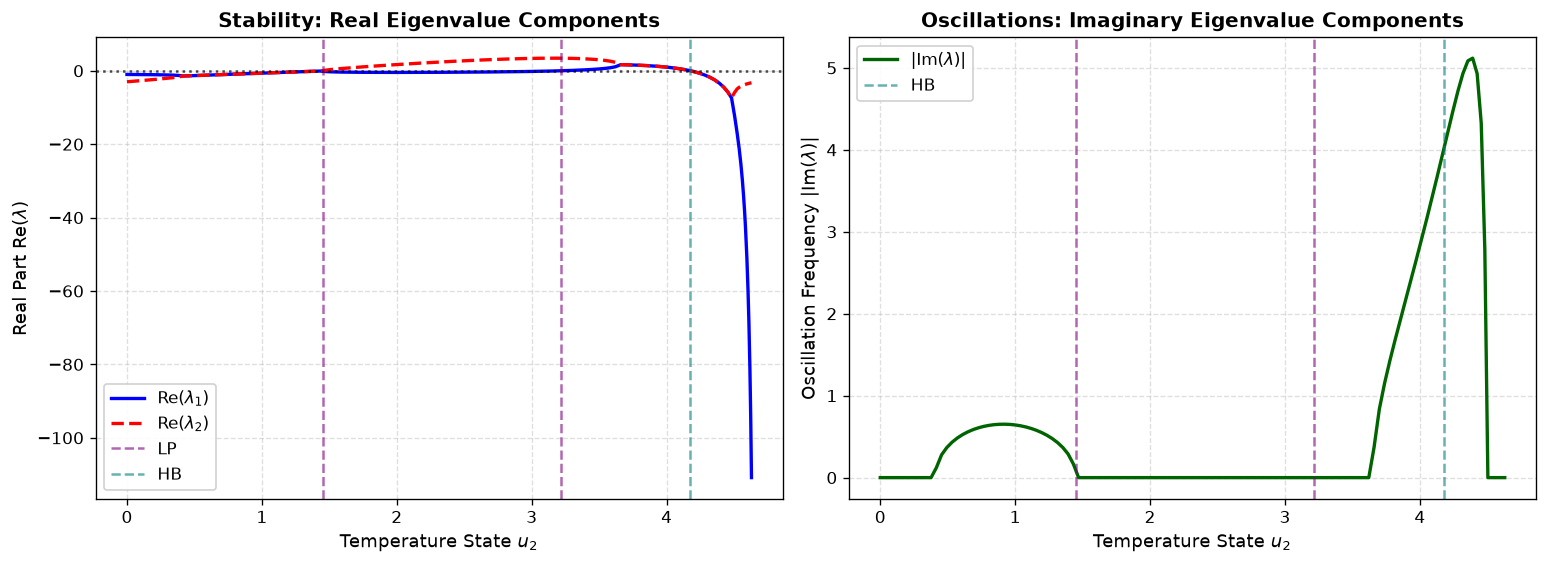

In [6]:
# Compute eigenvalues at every continuation point
eigenvalues = []
for u_pt, p_pt in zip(res.u, res.p, strict=True):
    Ju = prob.jacobian_u(u_pt, p_pt)
    eigs = np.linalg.eigvals(np.asarray(Ju))
    eigenvalues.append(eigs)

eigenvalues = np.asarray(eigenvalues)
u2_arr = np.asarray(res.u)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8), dpi=120)

# Real parts
ax1.plot(u2_arr, np.real(eigenvalues[:, 0]), "b-", linewidth=2, label=r"$\mathrm{Re}(\lambda_1)$")
ax1.plot(u2_arr, np.real(eigenvalues[:, 1]), "r--", linewidth=2, label=r"$\mathrm{Re}(\lambda_2)$")
ax1.axhline(0, color="black", linestyle=":", alpha=0.7)

# Mark bifurcations using index to avoid dataclass array equality check
for idx, lp in enumerate(lps):
    ax1.axvline(float(lp.u[1]), color="purple", linestyle="--", alpha=0.6, label="LP" if idx == 0 else "")
ax1.axvline(float(hb.u[1]), color="teal", linestyle="--", alpha=0.6, label="HB")

ax1.set_xlabel("Temperature State $u_2$", fontsize=11)
ax1.set_ylabel(r"Real Part $\mathrm{Re}(\lambda)$", fontsize=11)
ax1.set_title("Stability: Real Eigenvalue Components", fontsize=12, weight="bold")
ax1.legend(loc="lower left", framealpha=0.9)
ax1.grid(True, linestyle="--", alpha=0.4)

# Imaginary parts
ax2.plot(u2_arr, np.abs(np.imag(eigenvalues[:, 0])), color="darkgreen", linewidth=2, label=r"$|\mathrm{Im}(\lambda)|$")
for lp in lps:
    ax2.axvline(float(lp.u[1]), color="purple", linestyle="--", alpha=0.6)
ax2.axvline(float(hb.u[1]), color="teal", linestyle="--", alpha=0.6, label="HB")

ax2.set_xlabel("Temperature State $u_2$", fontsize=11)
ax2.set_ylabel(r"Oscillation Frequency $|\mathrm{Im}(\lambda)|$", fontsize=11)
ax2.set_title("Oscillations: Imaginary Eigenvalue Components", fontsize=12, weight="bold")
ax2.legend(loc="upper left", framealpha=0.9)
ax2.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


## 7. Bifurcation Diagrams ($p_1$ vs $u_1$ and $p_1$ vs $u_2$)

Finally, we display the complete bifurcation diagrams. Notice how:
- Solid lines indicate stable equilibrium branches ($\mathrm{Re}(\lambda) < 0$).
- Dashed lines indicate unstable branches ($\mathrm{Re}(\lambda) > 0$).
- Purple circles mark Fold points (LP 1 and LP 2).
- Teal triangle marks the Hopf bifurcation (HB).


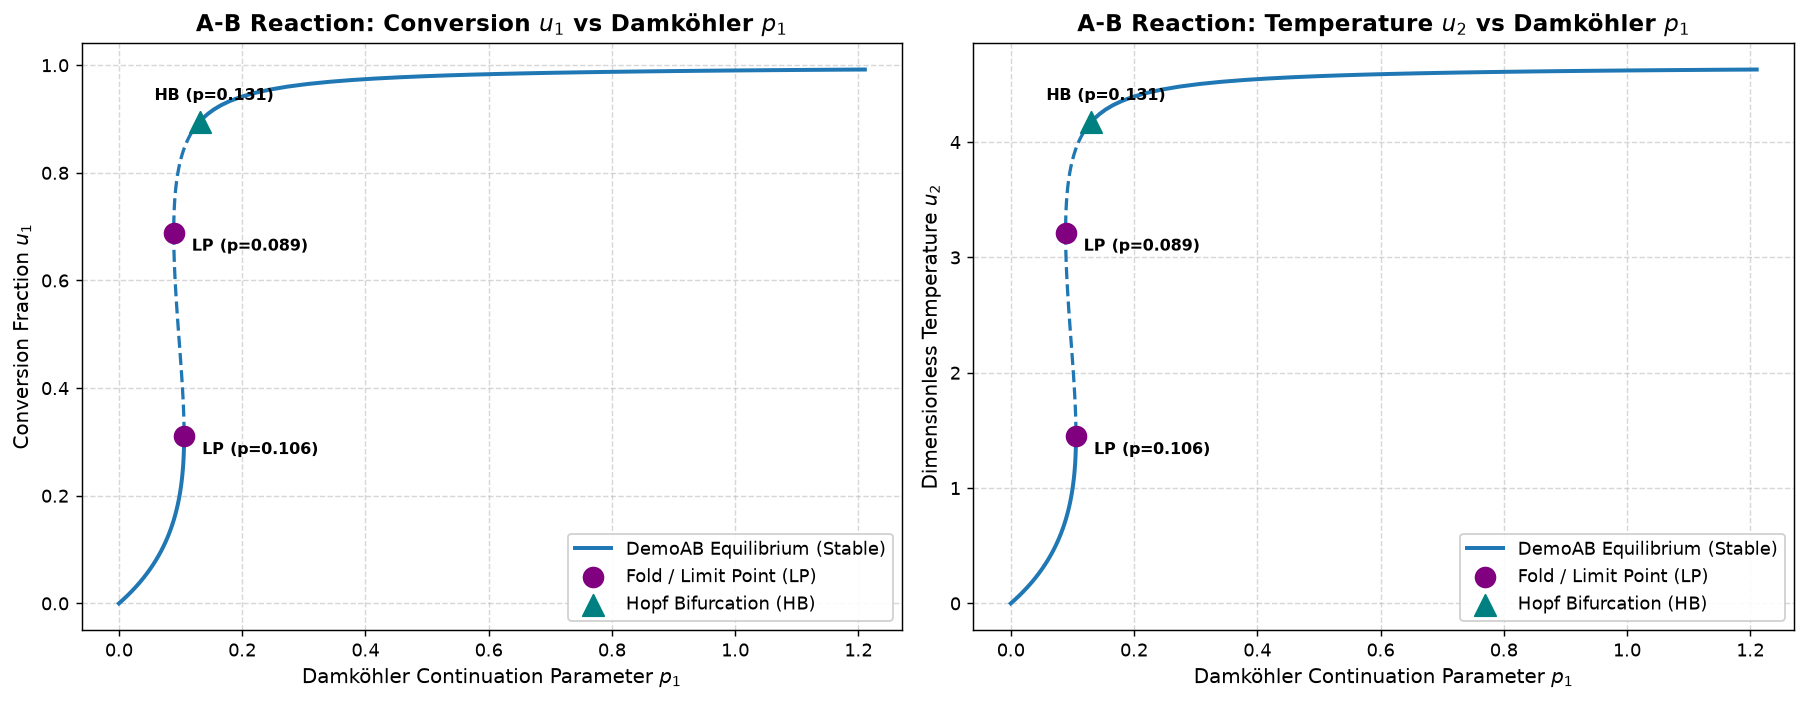

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=130)

# Diagram for Conversion u1 vs p1
plot_diagram(
    res,
    state_index=0,
    ax=axes[0],
    title="A-B Reaction: Conversion $u_1$ vs Damköhler $p_1$",
    xlabel="Damköhler Continuation Parameter $p_1$",
    ylabel="Conversion Fraction $u_1$",
    show_special_points=True,
    annotate_points=True,
)

# Diagram for Temperature u2 vs p1
plot_diagram(
    res,
    state_index=1,
    ax=axes[1],
    title="A-B Reaction: Temperature $u_2$ vs Damköhler $p_1$",
    xlabel="Damköhler Continuation Parameter $p_1$",
    ylabel="Dimensionless Temperature $u_2$",
    show_special_points=True,
    annotate_points=True,
)

plt.tight_layout()
plt.show()
